# User Behavior Classification


## Objectif

- Exploration descriptive et visualisations clés
- Préparation/encodage des variables et normalisation
- Tuning de plusieurs modèles supervisés (LogReg, SVM, RandomForest, XGBoost)
- Comparaison de performances, interprétation et sauvegarde du meilleur pipeline


### Import des librairies


In [23]:
import math
import time
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib import pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 3)

RANDOM_STATE = 42


### Chargement et aperçu des données


In [24]:
from feature_builder import build_feature_dataframe

df_features = build_feature_dataframe()
print(f"Shape: {df_features.shape}")
display(df_features.head())


Shape: (3279, 90)


,user,browser,browser_code,total_tokens,nb_actions,nb_time_marks,nb_unique_actions,ratio_unique_actions,nb_screens,nb_unique_screens,nb_confs,nb_unique_confs,nb_chaines,nb_unique_chaines,vitesse_moyenne,count_dialogue_actions,count_bouton_actions,count_saisie_actions,count_toast_actions,count_filtrage_actions,count_double_clic_actions,main_action,main_action_share,main_screen,main_conf,main_chaine,actions_per_time_span,time_total,time_mean,time_std,time_min,time_max,time_span,time_count,avg_time_gap,action_count__execution_d_un_bouton,action_count__saisie_dans_un_champ,action_count__selection_d_un_ecran,action_count__fermeture_d_une_dialogue,action_count__affichage_d_une_dialogue,action_count__lancement_d_une_action_generique,action_count__selection_dun_onglet,action_count__raccourci,action_count__creation_d_un_ecran,action_count__chainage,action_count__double_clic,action_count__retour_sur_un_ecran,action_count__affichage_d_un_toast,action_count__clic_sur_une_grille_d_historique_de_recherche,action_count__entree_en_saisie_dans_un_formulaire,action_count__filtrage_tri,action_count__selection_d_un_flag,action_count__lancement_d_une_stat,action_count__lancement_d_un_tableau_de_bord,action_count__action_de_table,screen_count__maint,screen_count__infologic_core_gui_controllers_blankcontroller,screen_count__infologic_core_fichierscontroller,screen_count__infologic_crm_modules_crm_planning_planning_planningcontroller,screen_count__dev,screen_count__infologic_infoc_statmodif_fichierbase_statfbcontroller,screen_count__infologic_core_gui_controllers_nested_inputformnestedwindow,screen_count__infologic_orga_modules_or_fichiertravail_instanceform,screen_count__infologic_core_accueil_accueilcontroller,screen_count__infologic_core_gui_controllers_nested_homeview_inputformhomeview,screen_count__param,screen_count__infologic_crm_modules_crm_compte_compteform,screen_count__infologic_acti_modules_at_activites_ficheactivite_actificheactivitecontroller,screen_count__bug,screen_count__testobs,conf_count__def_03_24,conf_count__def_07_23,conf_count__std,conf_count__installateur,conf_count__telem_minimal,conf_count__001,conf_count__mt_appeln1,conf_count__accueil_inst,conf_count__005,conf_count__dispatch,chaine_count__vt,chaine_count__gp,chaine_count__edi,chaine_count__tec,chaine_count__ot,chaine_count__sv,chaine_count__gesco,chaine_count__jcp,chaine_count__st,chaine_count__web
0,nuh,Firefox,3,3128,2514,614,19,0.008,191,7,7,3,899,2,0.852,719,698,198,311,161,87,Exécution d'un bouton,0.278,MAINT,DEF_03/24,JCP,0.867,895130.0,1457.866,839.342,5.0,2905.0,2900.0,614,4.731,698,198,23,369,350,124,6,0,72,8,87,2,311,1,0,161,0,85,0,11,89,4,0,0,0,0,1,0,5,85,0,0,4,0,0,3,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,822,0,0
1,muz,Google Chrome,0,136,90,46,11,0.122,8,5,4,2,43,2,0.365,4,33,34,1,0,0,Saisie dans un champ,0.378,infologic.orga.modules.OR_FICHIERTRAVAIL.Insta...,TELEM_MINIMAL,DB,0.400,5405.0,117.500,66.380,5.0,230.0,225.0,46,5.000,33,34,3,2,2,5,3,1,3,3,0,0,1,0,0,0,0,0,0,0,2,1,0,0,0,0,1,3,0,0,0,0,0,0,0,2,0,0,0,2,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0
2,zrx,Microsoft Edge,1,766,608,158,21,0.035,94,17,35,7,52,2,0.796,73,122,46,7,1,22,Exécution d'un bouton,0.201,DEMTEST,DEF_07/23,MES,0.816,59285.0,375.222,213.150,5.0,750.0,745.0,158,4.745,122,46,68,38,35,35,21,39,36,32,22,4,7,72,0,1,0,0,0,6,0,5,1,9,10,0,5,6,0,0,5,0,2,0,15,0,13,2,8,4,3,0,4,0,0,0,13,0,0,0,0,0,0,0,0
3,pou,Firefox,3,1199,886,313,19,0.021,249,10,9,4,203,1,0.596,84,279,84,2,5,2,Exécution d'un bouton,0.315,MAINT,DEF_03/24,JCP,0.615,229405.0,732.923,415.740,5.0,1445.0,1440.0,313,4.615,279,84,50,42,42,26,0,0,22,23,2,17,2,121,0,5,60,101,0,7,117,4,29,1,0,2,2,1,2,89,0,0,2,0,0,4,0,3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,203,0,0
4,ald,Google Chrome,0,233,173,60,14,0.081,21,8,7,4,11,2,0.607,20,60,36,1,0,2,Exécution d'un bouton,0.347,MAINT,INSTALLATEUR,GP,0.641,8185.0,136.417,79.210,5.0,275.0,270.0,60,4.576,60,14,19,10,10,7,0,0,10,4,2,0,1,10,22,0,0,0,0,3,6,0,3,3,0,0,1,2,0,0,0,0,0,0,1,2,1,0,2,2,0,0,0,0,0,0,8,0,0,0,0,0,0,3,0


In [25]:
print("Informations générales :")
df_features.info()

missing_values = (
    df_features.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame(name="missing_values")
)
display(missing_values.head(20))


Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3279 entries, 0 to 3278
Data columns (total 90 columns):
 #   Column                                                                                       Non-Null Count  Dtype  
---  ------                                                                                       --------------  -----  
 0   user                                                                                         3279 non-null   object 
 1   browser                                                                                      3279 non-null   object 
 2   browser_code                                                                                 3279 non-null   int64  
 3   total_tokens                                                                                 3279 non-null   int64  
 4   nb_actions                                                                                   3279 non-null   int64  
 5   nb_time_m

,missing_values
main_chaine,1051
main_conf,153
main_action,1
main_screen,1
nb_actions,0
nb_time_marks,0
browser_code,0
total_tokens,0
user,0
browser,0


### Exploration (EDA)


In [26]:
print("Statistiques descriptives (variables numériques) :")
display(df_features.describe().T)


Statistiques descriptives (variables numériques) :


,count,mean,std,min,25%,50%,75%,max
browser_code,3279.0,1.493,1.401,0.0,0.0,1.0,3.0,3.0
total_tokens,3279.0,850.239,1212.324,2.0,192.0,423.0,1019.0,14468.0
nb_actions,3279.0,692.360,1005.874,0.0,153.0,340.0,818.5,11977.0
nb_time_marks,3279.0,157.879,212.514,1.0,38.0,82.0,197.5,2491.0
nb_unique_actions,3279.0,16.996,4.322,0.0,14.0,17.0,20.0,29.0
...,...,...,...,...,...,...,...,...
chaine_count__sv,3279.0,7.222,42.769,0.0,0.0,0.0,0.0,837.0
chaine_count__gesco,3279.0,6.762,53.800,0.0,0.0,0.0,0.0,1739.0
chaine_count__jcp,3279.0,6.604,52.770,0.0,0.0,0.0,0.0,1058.0
chaine_count__st,3279.0,5.233,38.811,0.0,0.0,0.0,0.0,1184.0


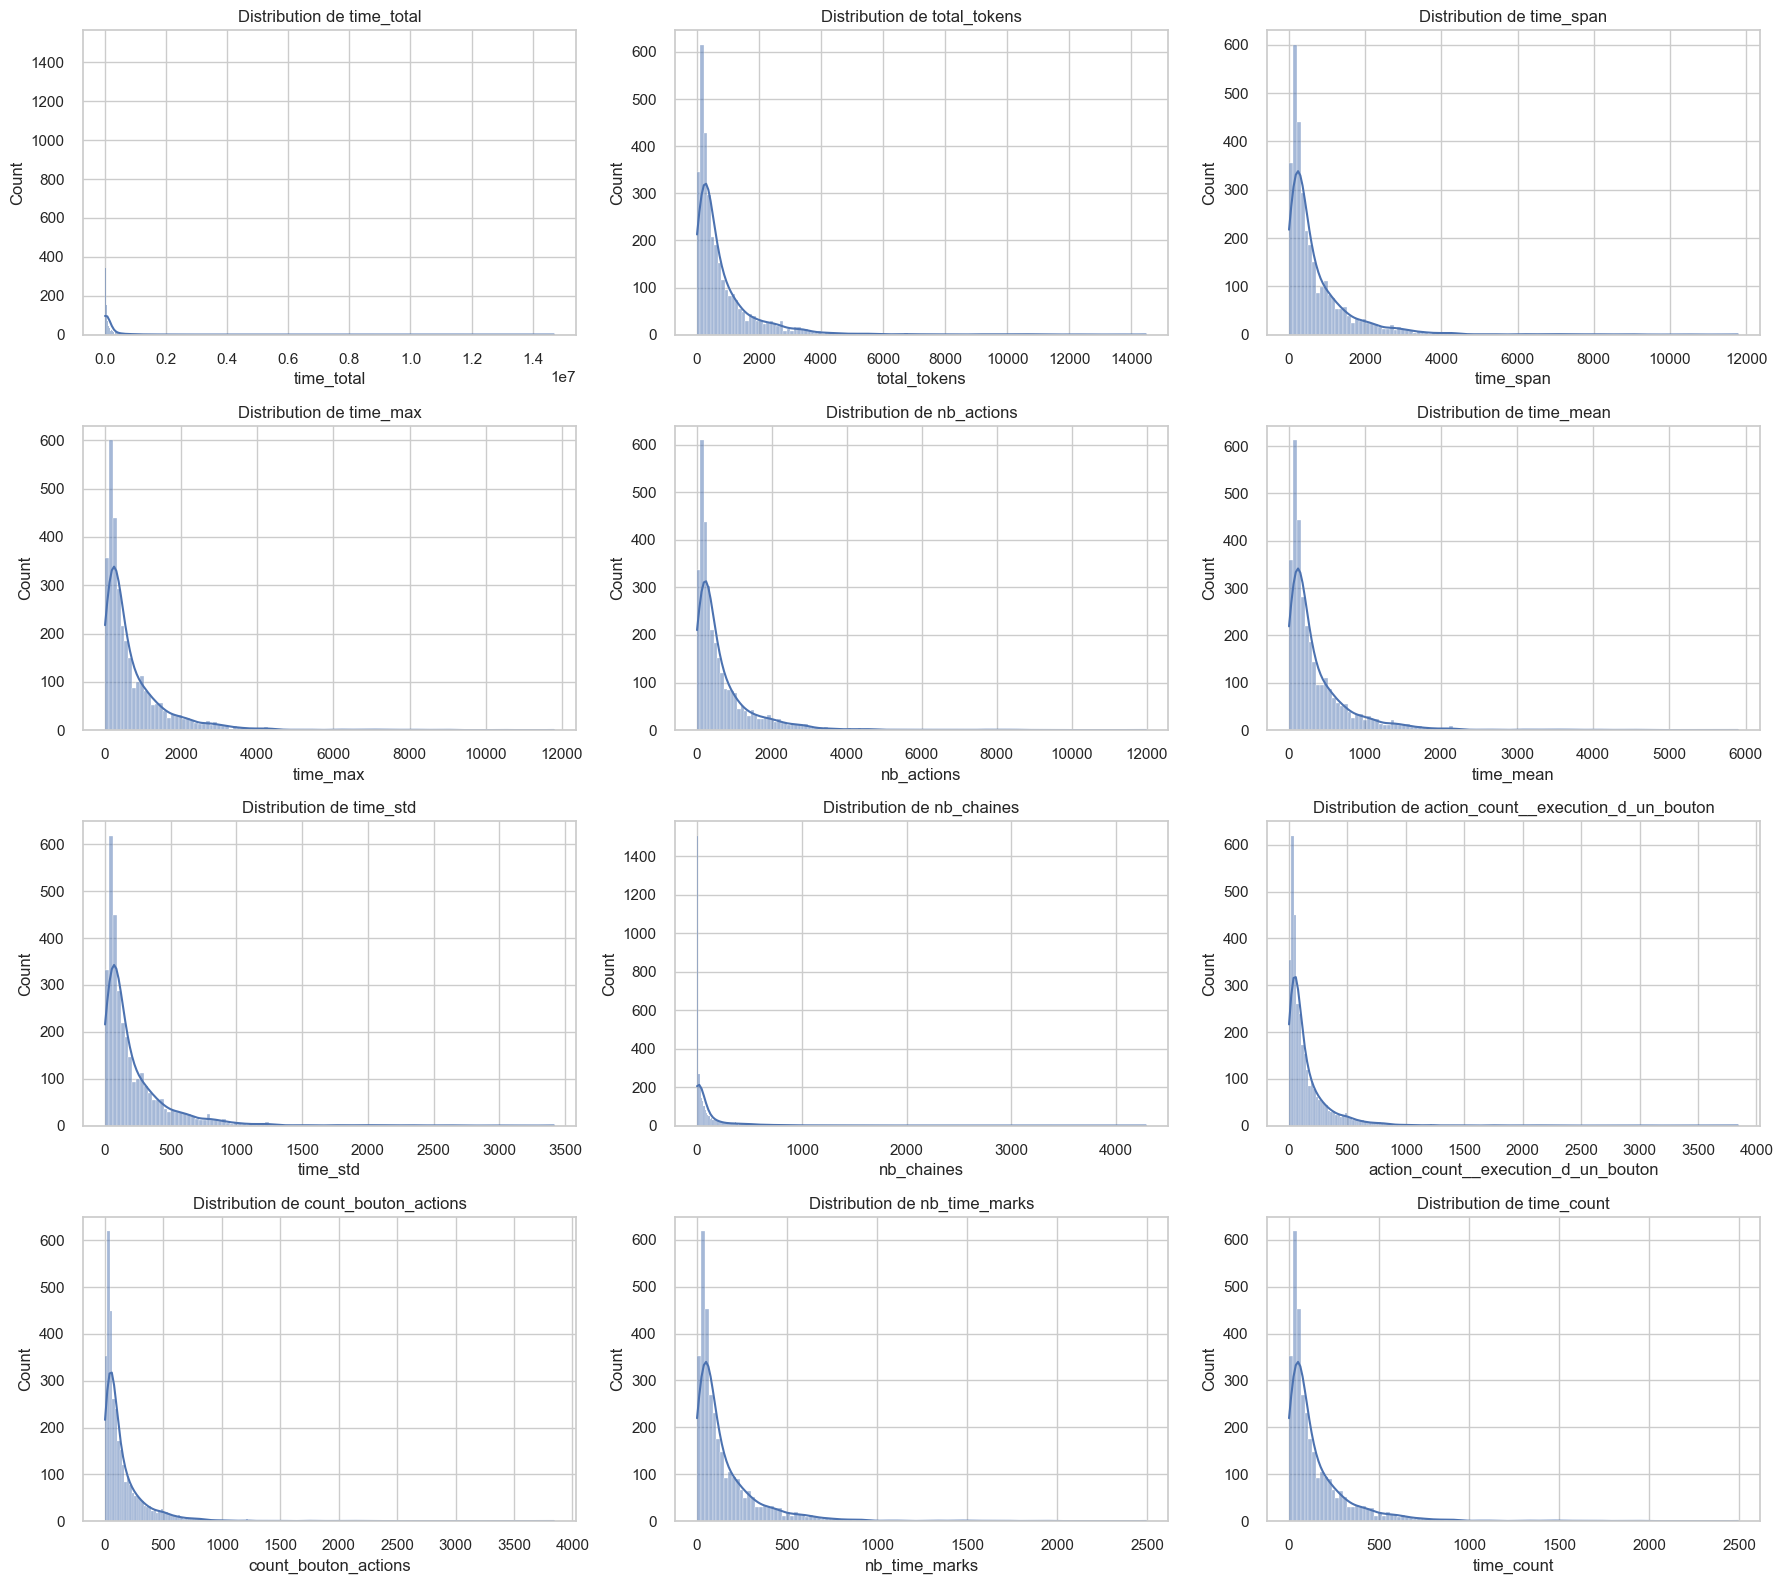

In [27]:
numeric_columns = df_features.select_dtypes(include=[np.number]).columns.tolist()
if not numeric_columns:
    print("Aucune variable numérique détectée dans df_features.")
else:
    numeric_variances = df_features[numeric_columns].var().sort_values(ascending=False)
    top_numeric = numeric_variances.head(12).index.tolist()
    rows = math.ceil(len(top_numeric) / 3)
    fig, axes = plt.subplots(rows, 3, figsize=(18, rows * 4))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, top_numeric):
        sns.histplot(df_features[col].dropna(), kde=True, ax=ax)
        ax.set_title(f"Distribution de {col}")
    for ax in axes[len(top_numeric):]:
        ax.axis("off")
    plt.tight_layout()


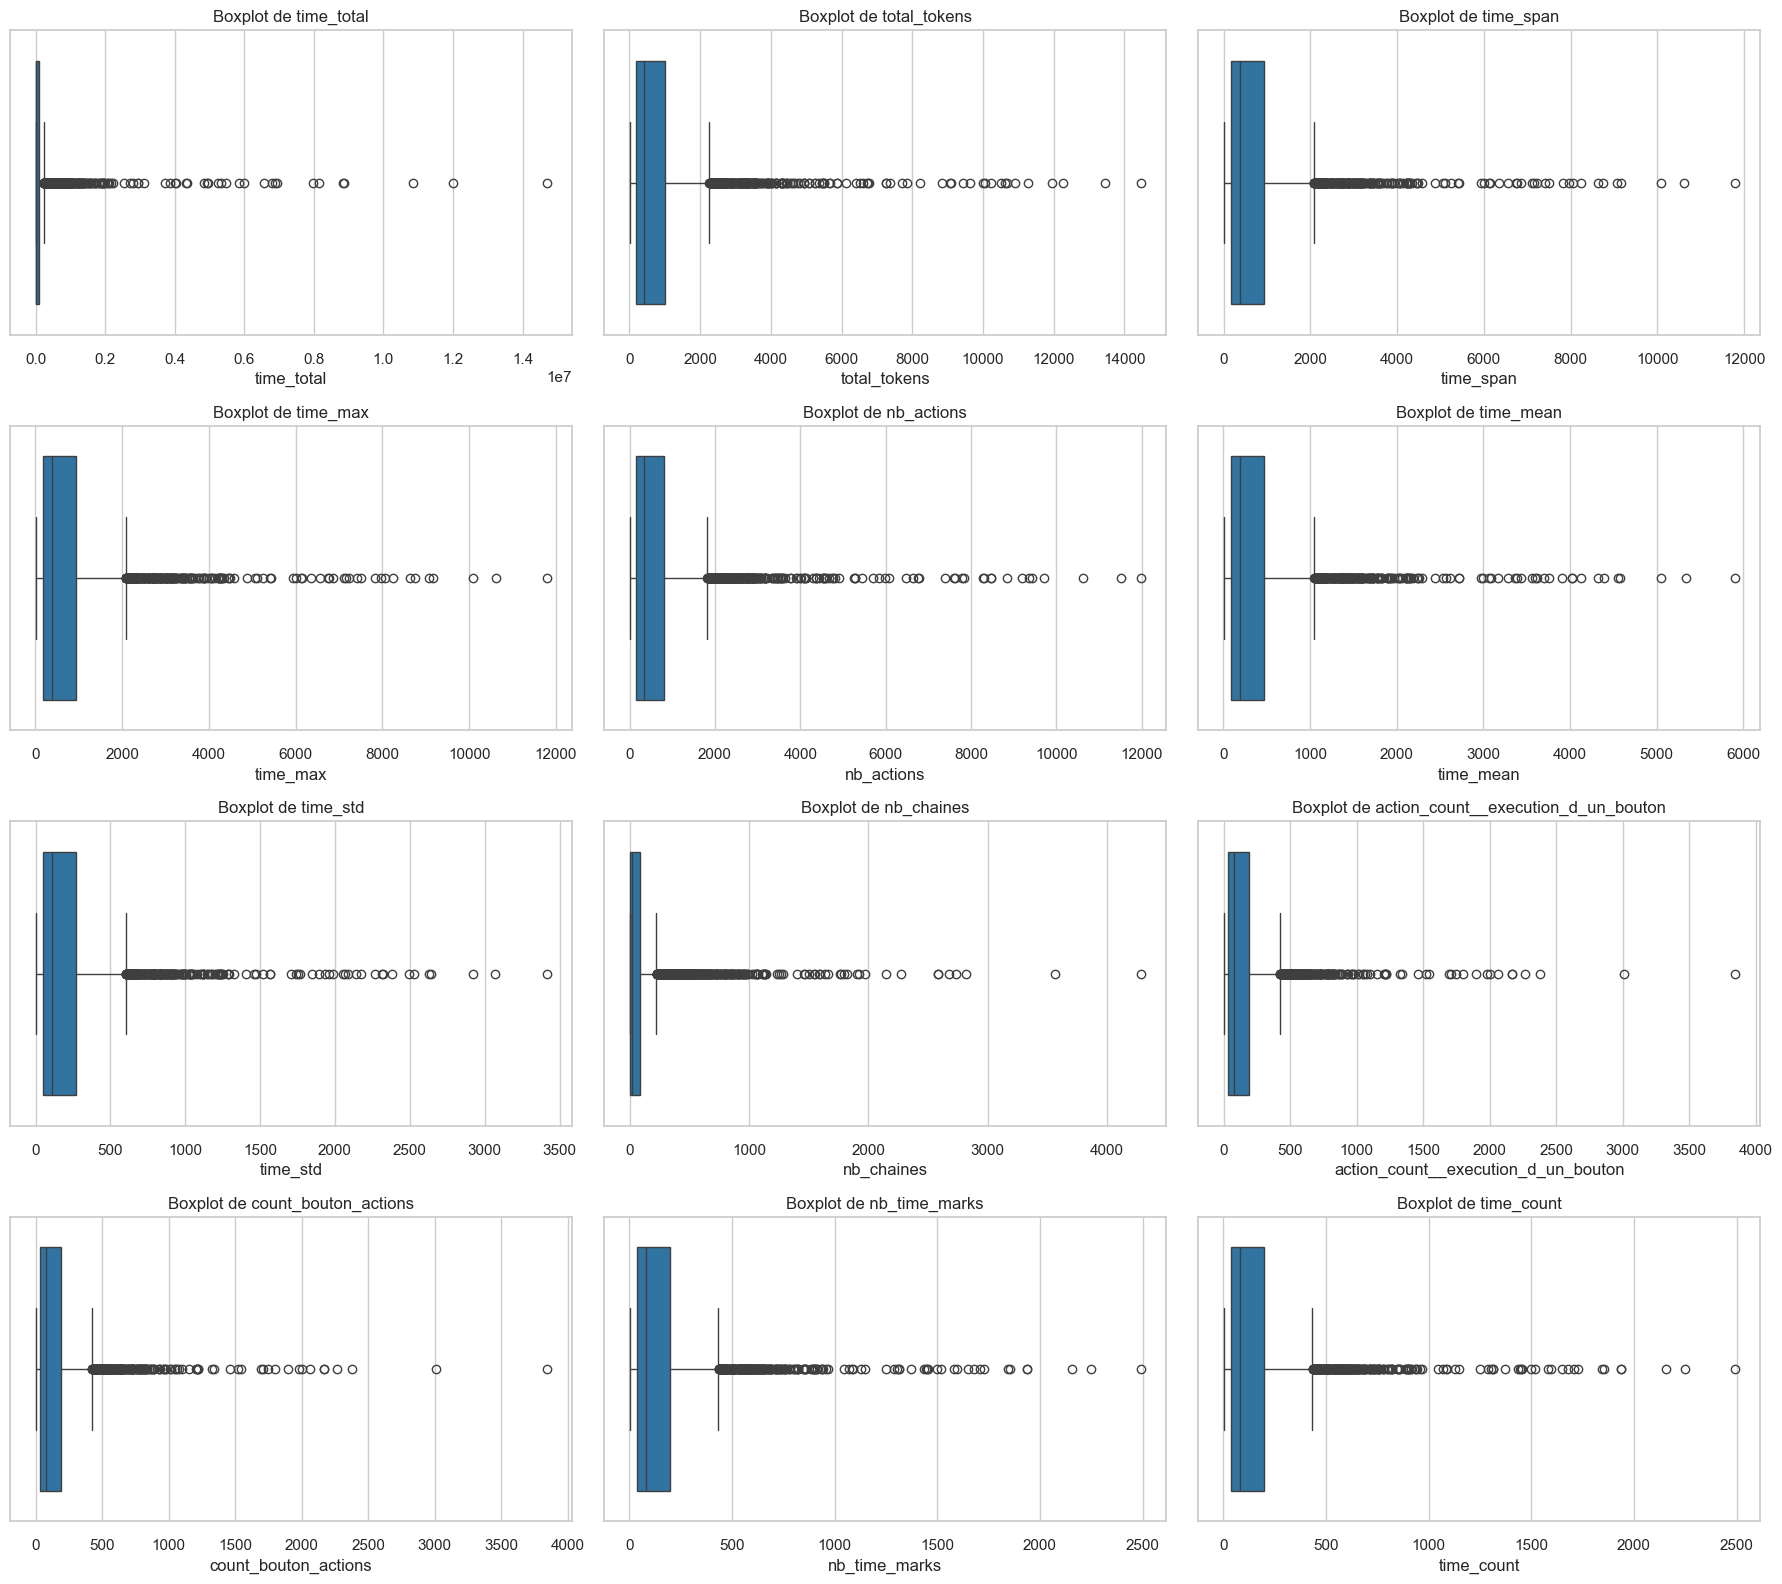

In [28]:
numeric_columns = df_features.select_dtypes(include=[np.number]).columns.tolist()
numeric_variances = df_features[numeric_columns].var().sort_values(ascending=False)
top_numeric = numeric_variances.head(12).index.tolist()
rows = math.ceil(len(top_numeric) / 3)
fig, axes = plt.subplots(rows, 3, figsize=(18, rows * 4))
axes = np.array(axes).reshape(-1)
for ax, col in zip(axes, top_numeric):
    sns.boxplot(x=df_features[col], ax=ax, color="#1f77b4")
    ax.set_title(f"Boxplot de {col}")
for ax in axes[len(top_numeric):]:
    ax.axis("off")
plt.tight_layout()



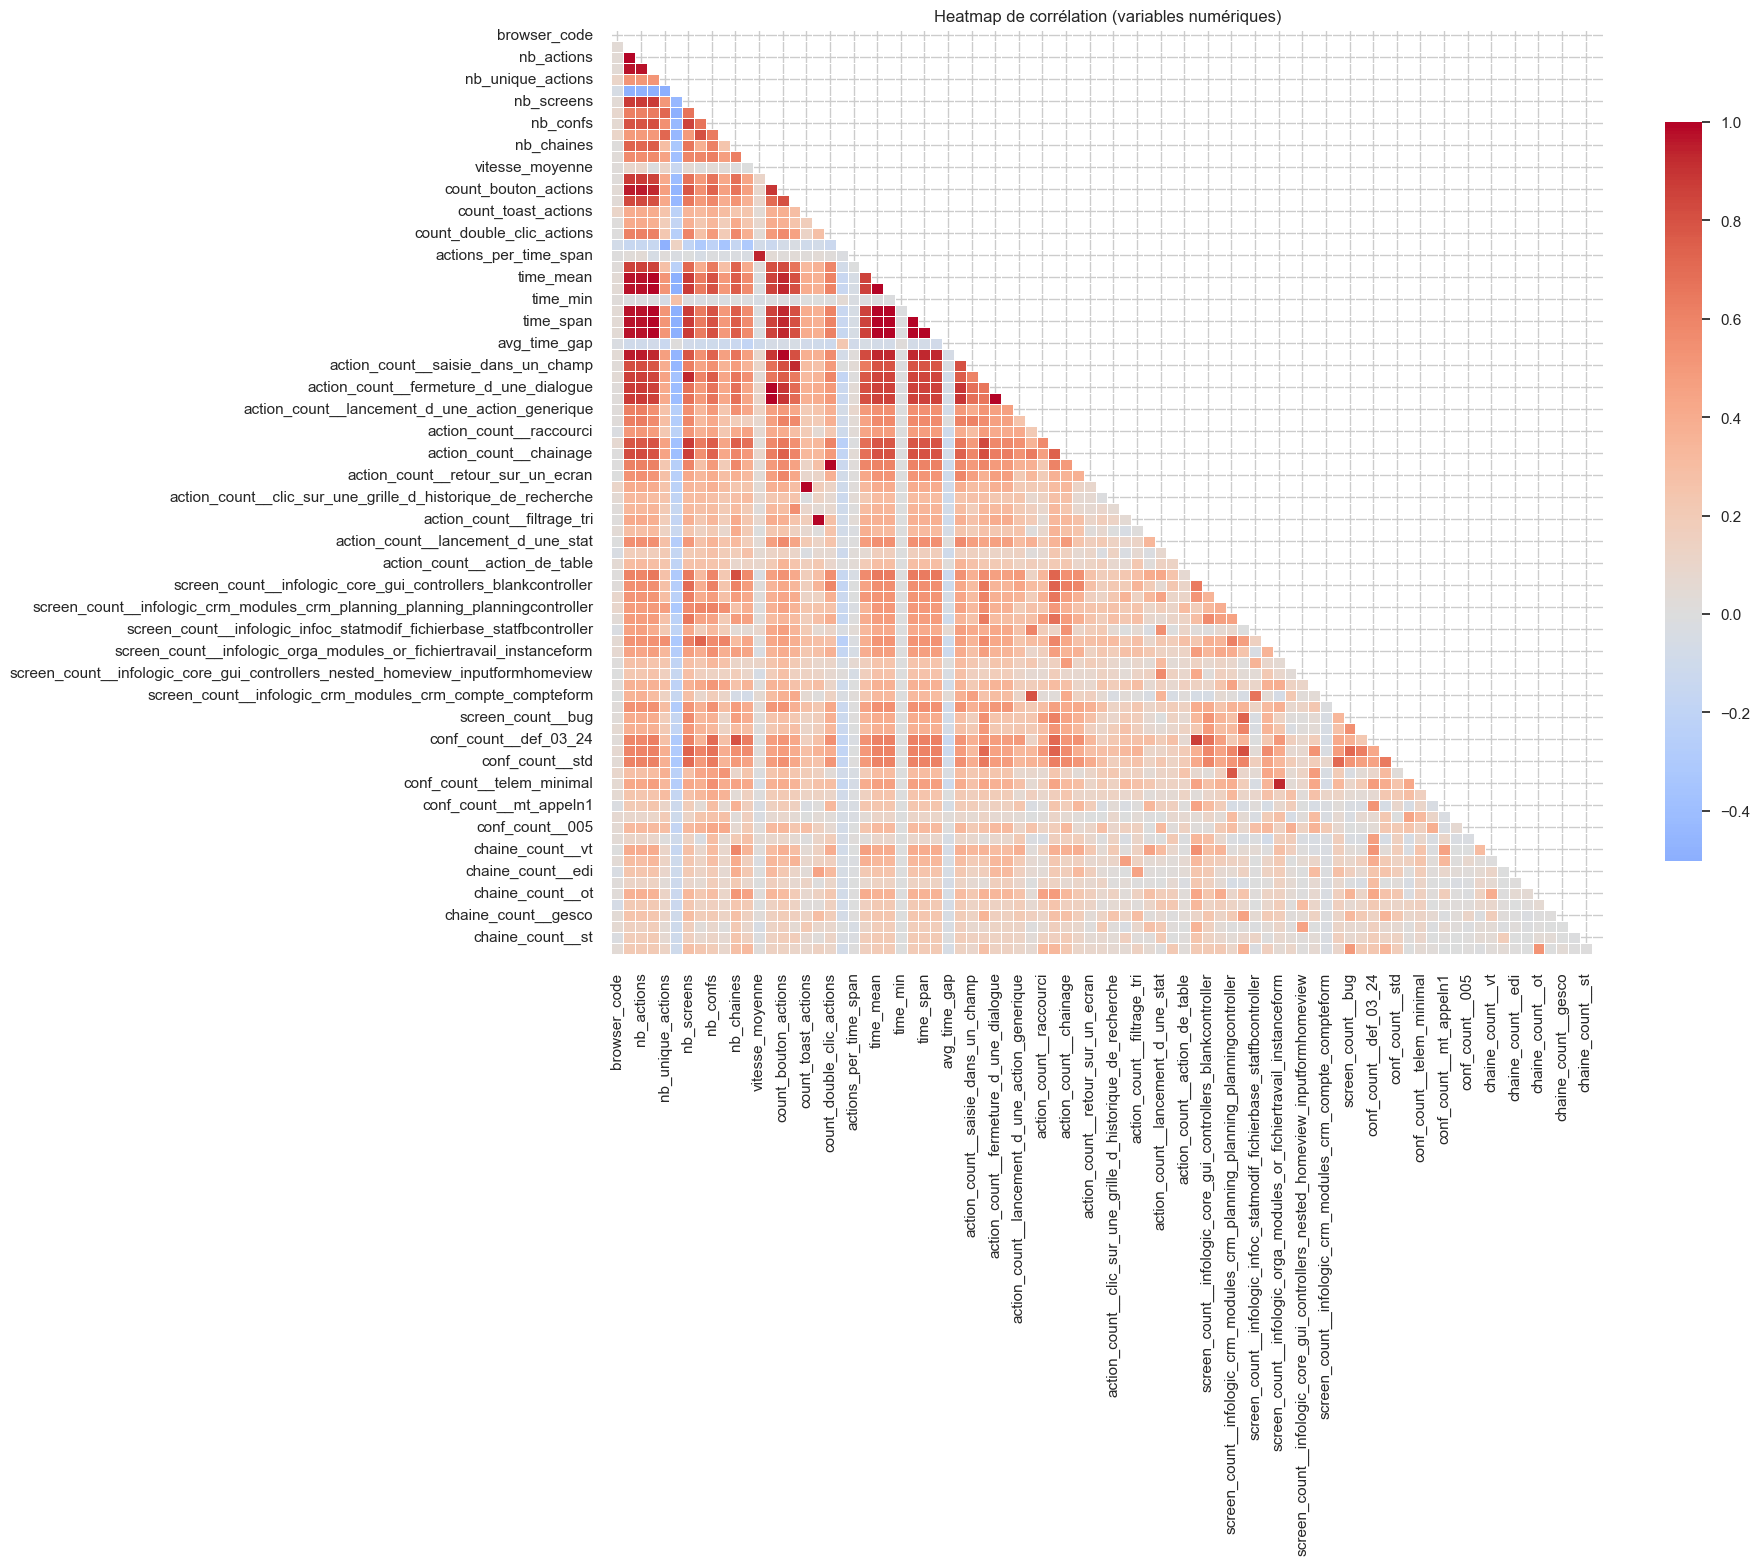

In [29]:
numeric_df = df_features.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    mask=mask,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
plt.title("Heatmap de corrélation (variables numériques)")
plt.show()



#### Corrélations fortes et multicolinéarité

- Corrélations ≥ 0,85 marquées comme fortes.
- Calcul du VIF pour confirmer le risque de multicolinéarité.
- Liste de colonnes candidates à retirer automatiquement avant le modèle.


In [30]:
CORR_THRESHOLD = 0.85

numeric_df = df_features.select_dtypes(include=[np.number])

if numeric_df.shape[1] > 1:
    corr_matrix_abs = numeric_df.corr().abs()
    upper = corr_matrix_abs.where(np.triu(np.ones_like(corr_matrix_abs), k=1).astype(bool))
    high_corr_pairs = (
        upper.stack()
        .reset_index()
        .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "corr"})
        .sort_values(by="corr", ascending=False)
    )
    high_corr_pairs = high_corr_pairs[high_corr_pairs["corr"] >= CORR_THRESHOLD]
    if high_corr_pairs.empty:
        features_to_drop_corr = []
        print(f"Aucune paire avec une corrélation ≥ {CORR_THRESHOLD}.")
    else:
        display(high_corr_pairs)
        mean_corr = corr_matrix_abs.mean()
        features_to_drop_corr = []
        already_tagged = set()
        for _, row in high_corr_pairs.iterrows():
            f1, f2 = row["feature_1"], row["feature_2"]
            if f1 in already_tagged or f2 in already_tagged:
                continue
            drop_candidate = f1 if mean_corr[f1] >= mean_corr[f2] else f2
            already_tagged.add(drop_candidate)
            features_to_drop_corr.append(drop_candidate)
        print(f"Features proposés à supprimer (|corr| ≥ {CORR_THRESHOLD}) : {features_to_drop_corr}")
else:
    high_corr_pairs = pd.DataFrame(columns=["feature_1", "feature_2", "corr"])
    features_to_drop_corr = []
    print("Pas assez de variables numériques pour analyser les corrélations fortes.")


,feature_1,feature_2,corr
1301,count_filtrage_actions,action_count__filtrage_tri,1.000
1361,count_double_clic_actions,action_count__double_clic,1.000
1232,count_toast_actions,action_count__affichage_d_un_toast,1.000
1085,count_bouton_actions,action_count__execution_d_un_bouton,1.000
269,nb_time_marks,time_count,1.000
...,...,...,...
1665,time_std,action_count__affichage_d_une_dialogue,0.857
275,nb_time_marks,action_count__affichage_d_une_dialogue,0.857
1895,time_count,action_count__affichage_d_une_dialogue,0.857
102,total_tokens,time_total,0.856


Features proposés à supprimer (|corr| ≥ 0.85) : ['count_filtrage_actions', 'count_double_clic_actions', 'count_toast_actions', 'count_bouton_actions', 'nb_time_marks', 'time_span', 'time_std', 'time_max', 'action_count__fermeture_d_une_dialogue', 'count_dialogue_actions', 'time_count', 'total_tokens', 'time_mean', 'nb_actions', 'vitesse_moyenne', 'screen_count__infologic_orga_modules_or_fichiertravail_instanceform', 'nb_screens', 'count_saisie_actions', 'action_count__execution_d_un_bouton', 'screen_count__maint']


In [31]:
VIF_THRESHOLD = 10.0

numeric_df = df_features.select_dtypes(include=[np.number])

if numeric_df.shape[1] > 1:
    from sklearn.linear_model import LinearRegression

    imputer = SimpleImputer(strategy="median")
    numeric_array = imputer.fit_transform(numeric_df)
    vif_scores = []
    for idx, feature in enumerate(numeric_df.columns):
        y = numeric_array[:, idx]
        X_rest = np.delete(numeric_array, idx, axis=1)
        if X_rest.shape[1] == 0:
            vif = np.nan
        else:
            model = LinearRegression()
            model.fit(X_rest, y)
            r2 = model.score(X_rest, y)
            vif = np.inf if r2 >= 0.999 else 1.0 / (1.0 - r2)
        vif_scores.append(vif)
    vif_df = pd.DataFrame({"feature": numeric_df.columns, "VIF": vif_scores}).sort_values("VIF", ascending=False)
    display(vif_df)
    high_vif_features = [
        row.feature
        for row in vif_df.itertuples()
        if np.isfinite(row.VIF) and row.VIF >= VIF_THRESHOLD
    ]
    print(f"Features avec VIF ≥ {VIF_THRESHOLD} : {high_vif_features}")
else:
    vif_df = pd.DataFrame(columns=["feature", "VIF"])
    high_vif_features = []
    print("Pas assez de variables numériques pour calculer le VIF.")


,feature,VIF
1,total_tokens,inf
2,nb_actions,inf
3,nb_time_marks,inf
16,count_toast_actions,inf
14,count_bouton_actions,inf
...,...,...
79,chaine_count__sv,1.737
71,conf_count__accueil_inst,1.718
82,chaine_count__st,1.684
28,avg_time_gap,1.558


Features avec VIF ≥ 10.0 : ['nb_screens', 'action_count__selection_d_un_ecran', 'screen_count__maint', 'nb_confs', 'conf_count__def_03_24', 'nb_chaines', 'conf_count__def_07_23', 'action_count__chainage', 'action_count__creation_d_un_ecran', 'vitesse_moyenne', 'screen_count__infologic_crm_modules_crm_planning_planning_planningcontroller', 'screen_count__infologic_orga_modules_or_fichiertravail_instanceform', 'conf_count__telem_minimal', 'conf_count__installateur', 'time_total', 'actions_per_time_span', 'action_count__selection_dun_onglet']


###  Nettoyage et préparation


In [32]:
target_col = "user"

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(df_features[target_col])
X = df_features.drop(columns=[target_col]).copy()
print(X.shape)
drop_candidates = set()
if "features_to_drop_corr" in globals():
    drop_candidates.update(features_to_drop_corr)
if "high_vif_features" in globals():
    drop_candidates.update(high_vif_features)
drop_candidates = [col for col in drop_candidates if col in X.columns]
if drop_candidates:
    X = X.drop(columns=drop_candidates)
    print(print(f"Shape avant/après : apres → {X.shape}"))
    print(f"Colonnes supprimées (corrélation/VIF) : {drop_candidates}")

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Nombre de colonnes numériques : {len(numeric_features)}")
print(f"Nombre de colonnes catégorielles : {len(categorical_features)}")
print(f"Nombre de classes cibles : {len(target_encoder.classes_)}")

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_encoder_kwargs = {"handle_unknown": "ignore"}
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(**categorical_encoder_kwargs)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)


(3279, 89)
Shape avant/après : apres → (3279, 56)
None
Colonnes supprimées (corrélation/VIF) : ['time_std', 'conf_count__def_07_23', 'screen_count__infologic_crm_modules_crm_planning_planning_planningcontroller', 'time_count', 'count_double_clic_actions', 'action_count__creation_d_un_ecran', 'count_filtrage_actions', 'time_mean', 'time_total', 'count_saisie_actions', 'count_bouton_actions', 'actions_per_time_span', 'action_count__execution_d_un_bouton', 'action_count__chainage', 'nb_actions', 'action_count__fermeture_d_une_dialogue', 'nb_confs', 'conf_count__def_03_24', 'time_max', 'total_tokens', 'nb_chaines', 'action_count__selection_dun_onglet', 'nb_time_marks', 'count_toast_actions', 'action_count__selection_d_un_ecran', 'time_span', 'nb_screens', 'conf_count__telem_minimal', 'screen_count__maint', 'conf_count__installateur', 'vitesse_moyenne', 'screen_count__infologic_orga_modules_or_fichiertravail_instanceform', 'count_dialogue_actions']
Nombre de colonnes numériques : 51
Nombre 

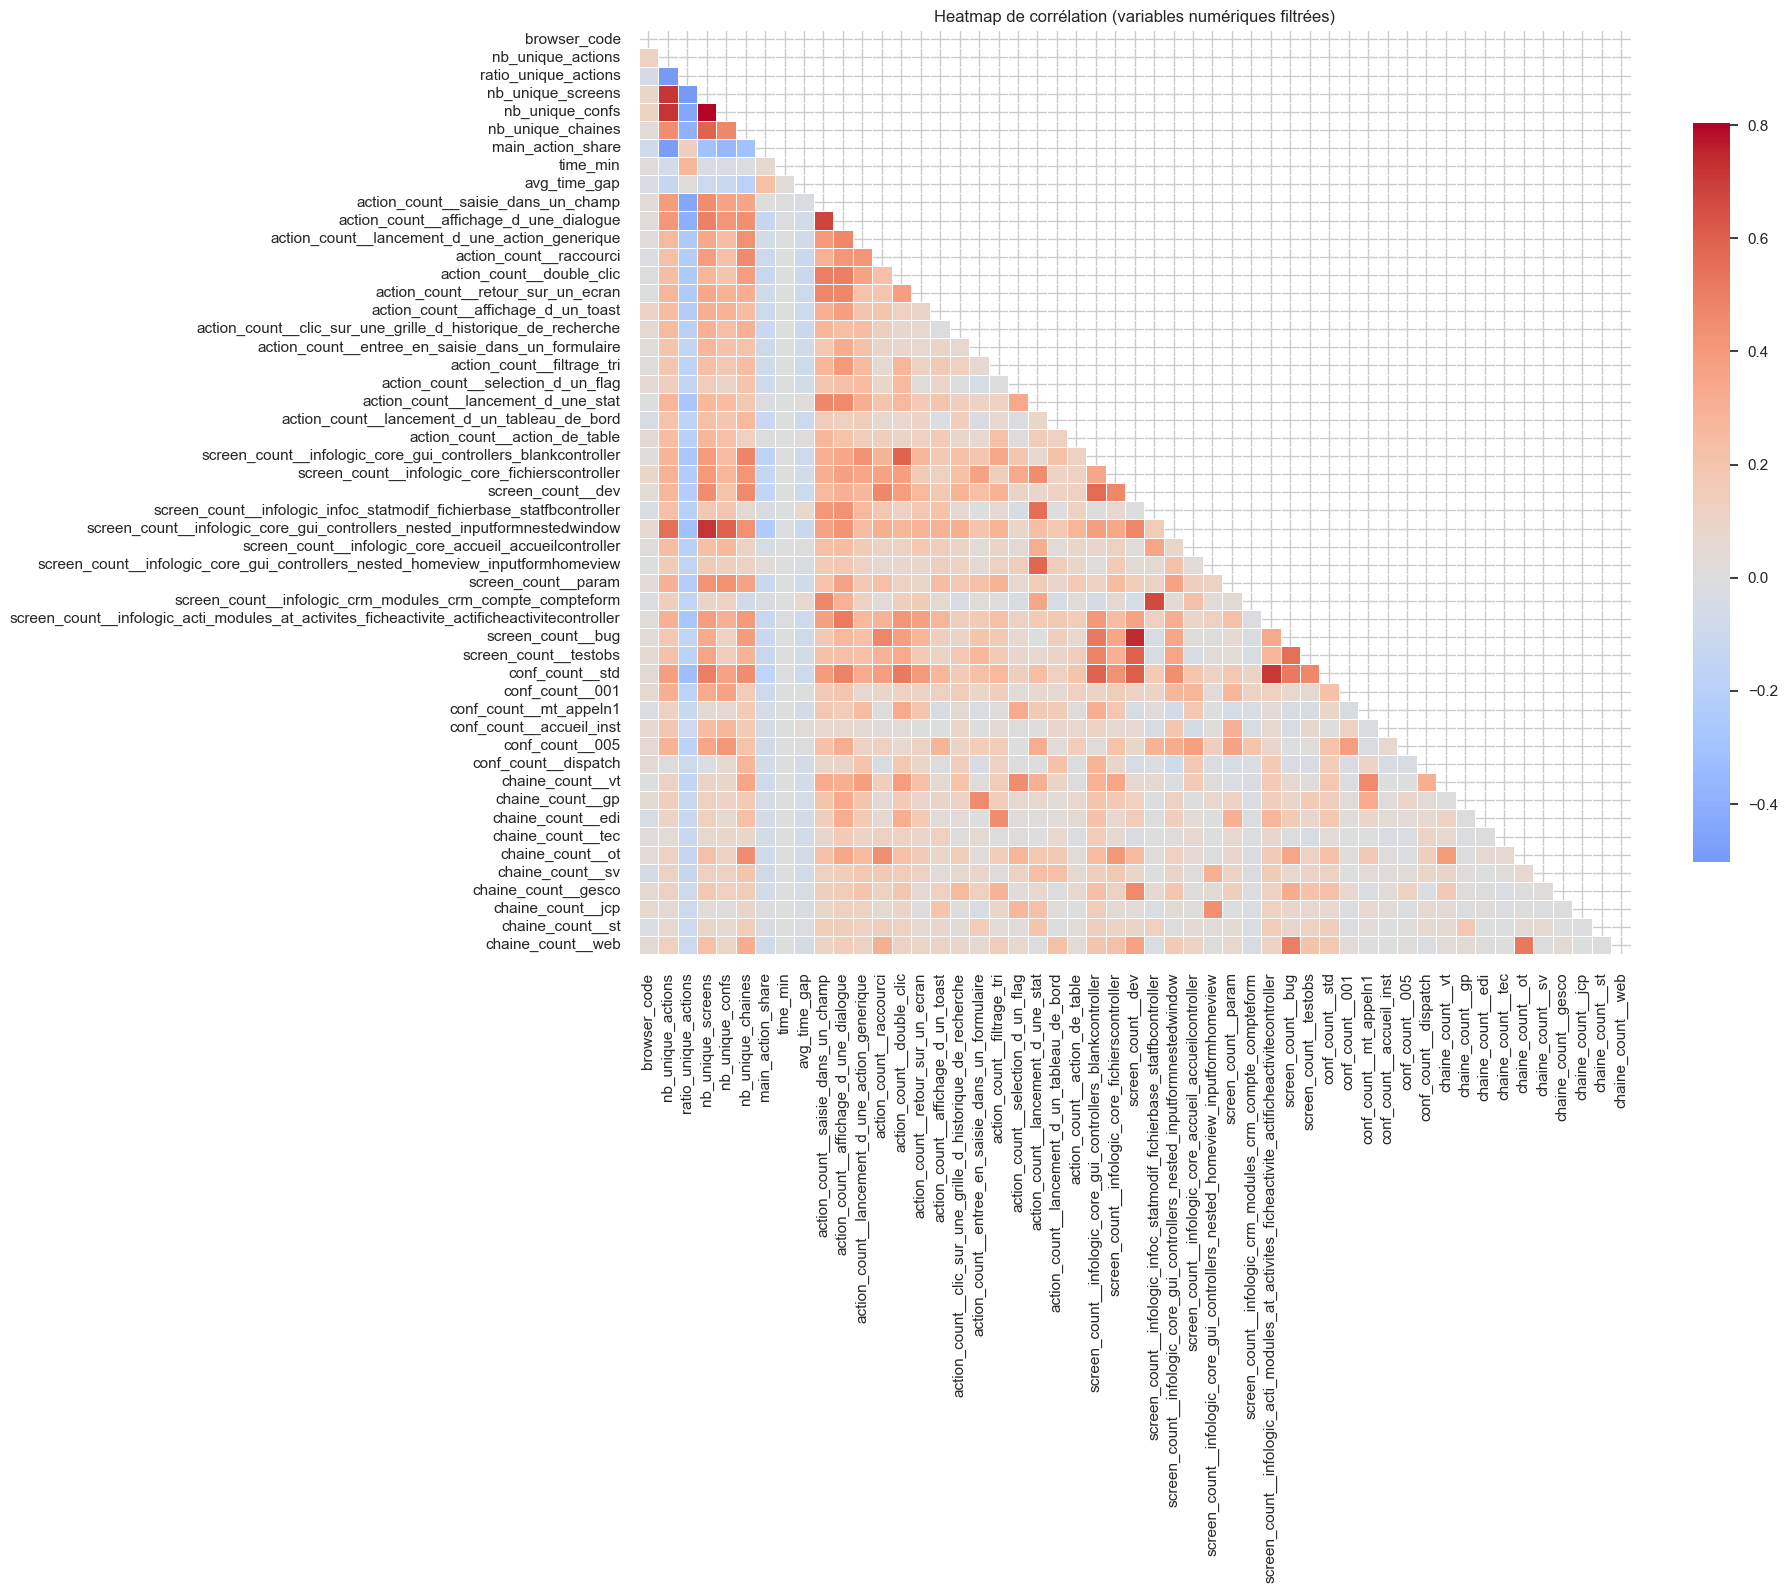

In [11]:
numeric_df = X.select_dtypes(include=[np.number])

corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    mask=mask,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
plt.title("Heatmap de corrélation (variables numériques filtrées)")
plt.show()


### Séparation des données


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"y_train classes : {len(np.unique(y_train))}")
print(f"y_test classes  : {len(np.unique(y_test))}")


X_train shape : (2623, 56)
X_test shape  : (656, 56)
y_train classes : 247
y_test classes  : 247


###  Modélisation et tuning


In [13]:
model_specs = {
    "Logistic Regression": (
        LogisticRegression(max_iter=1000, multi_class="auto"),
        {
            "model__C": [0.1, 1.0, 10.0],
            "model__penalty": ["l2"],
            "model__solver": ["lbfgs"],
        },
    ),
    "SVM (Linear)": (
        SVC(kernel="linear", probability=True, random_state=RANDOM_STATE),
        {
            "model__C": [0.5, 1.0, 5.0],
        },
    ),
    "SVM (RBF)": (
        SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
        {
            "model__C": [1.0, 5.0],
            "model__gamma": ["scale", "auto"],
        },
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        {
            "model__n_estimators": [200, 400],
            "model__max_depth": [None, 20, 40],
            "model__min_samples_split": [2, 5],
        },
    ),
}


model_specs["XGBoost"] = (
    XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        tree_method="hist",
        n_jobs=-1,
    ),
    {
        "model__n_estimators": [200, 400],
        "model__max_depth": [3, 5, 7],
        "model__learning_rate": [0.05, 0.1],
    },
)


results = []
best_models = {}

for model_name, (estimator, param_grid) in model_specs.items():
    print(f"=== {model_name} ===")
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", estimator),
        ]
    )

    search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=5,
        scoring="f1_macro",
        n_jobs=-1,
        verbose=1,
    )

    start_time = time.time()
    search.fit(X_train, y_train)
    train_time = time.time() - start_time

    best_pipeline = search.best_estimator_
    best_models[model_name] = best_pipeline

    y_pred = best_pipeline.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

    roc_auc = np.nan
    if hasattr(best_pipeline, "predict_proba"):
        try:
            y_scores = best_pipeline.predict_proba(X_test)
            roc_auc = roc_auc_score(y_test, y_scores, multi_class="ovr", average="macro")
        except Exception as exc:
            print(f"ROC-AUC non calculable pour {model_name} : {exc}")
    elif hasattr(best_pipeline, "decision_function"):
        try:
            decision_scores = best_pipeline.decision_function(X_test)
            roc_auc = roc_auc_score(y_test, decision_scores, multi_class="ovr", average="macro")
        except Exception as exc:
            print(f"ROC-AUC non calculable pour {model_name} : {exc}")

    print(f"Meilleurs hyperparamètres : {search.best_params_}")
    print(f"Score CV (f1_macro)    : {search.best_score_:.4f}")
    print(f"Temps d'entraînement   : {train_time:.2f} s")
    print(f"Accuracy (test)        : {accuracy:.4f}")
    print(f"Precision (test)       : {precision:.4f}")
    print(f"Recall (test)          : {recall:.4f}")
    print(f"F1-score (test)        : {f1:.4f}")
    print(f"ROC-AUC (test)         : {roc_auc if not np.isnan(roc_auc) else 'N/A'}")

    class_count = len(target_encoder.classes_)
    if class_count <= 30:
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(cm, display_labels=target_encoder.classes_)
        fig, ax = plt.subplots(figsize=(8, 6))
        disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
        ax.set_title(f"Confusion Matrix - {model_name}")
        plt.tight_layout()
        plt.show()
    else:
        print(f"Confusion matrix non affichée (trop de classes : {class_count}).")

    if class_count <= 30:
        print("Classification report :")
        print(
            classification_report(
                y_test,
                y_pred,
                target_names=target_encoder.classes_,
                zero_division=0,
            )
        )
    else:
        print("Rapport de classification non affiché (trop de classes).")

    results.append(
        {
            "model": model_name,
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "roc_auc": roc_auc,
            "train_time": train_time,
        }
    )


=== Logistic Regression ===
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Meilleurs hyperparamètres : {'model__C': 10.0, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Score CV (f1_macro)    : 0.6680
Temps d'entraînement   : 18.16 s
Accuracy (test)        : 0.7607
Precision (test)       : 0.7270
Recall (test)          : 0.7101
F1-score (test)        : 0.6977
ROC-AUC (test)         : 0.9832984751035599
Confusion matrix non affichée (trop de classes : 247).
Rapport de classification non affiché (trop de classes).
=== SVM (Linear) ===
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Meilleurs hyperparamètres : {'model__C': 0.5}
Score CV (f1_macro)    : 0.6200
Temps d'entraînement   : 17.38 s
Accuracy (test)        : 0.7073
Precision (test)       : 0.6703
Recall (test)          : 0.6575
F1-score (test)        : 0.6425
ROC-AUC (test)         : 0.978532027915703
Confusion matrix non affichée (trop de classes : 247).
Rapport de classification non affiché (trop de c

In [14]:
results_df = pd.DataFrame(results).sort_values(by="f1", ascending=False).reset_index(drop=True)
print("Résultats comparatifs :")
display(results_df)


Résultats comparatifs :


,model,accuracy,precision,recall,f1,roc_auc,train_time
0,Random Forest,0.829,0.821,0.800,0.794,0.996,87.380
1,Logistic Regression,0.761,0.727,0.710,0.698,0.983,18.164
2,XGBoost,0.770,0.719,0.710,0.698,0.985,353.988
3,SVM (Linear),0.707,0.670,0.657,0.643,0.979,17.378
4,SVM (RBF),0.666,0.636,0.593,0.585,0.969,28.509


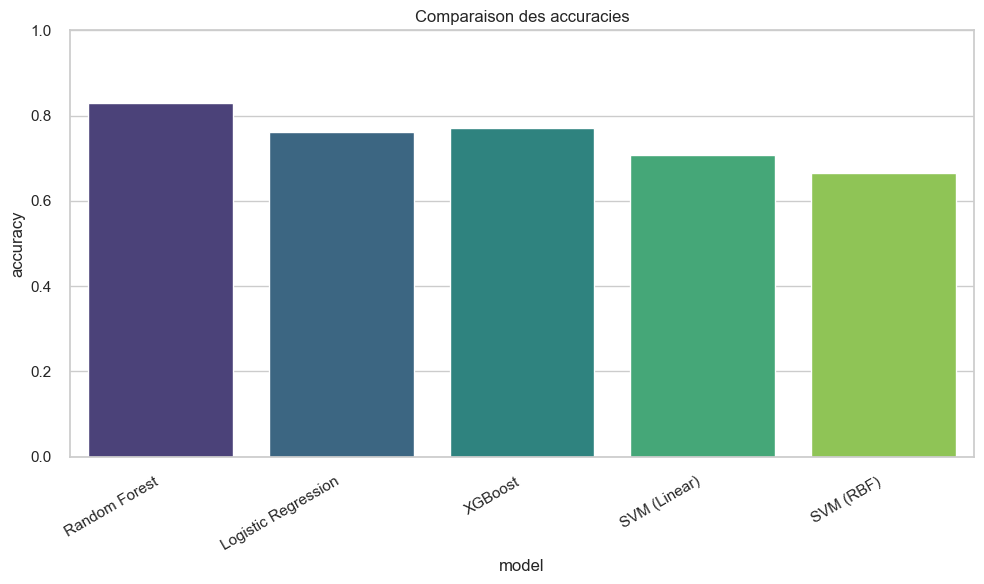

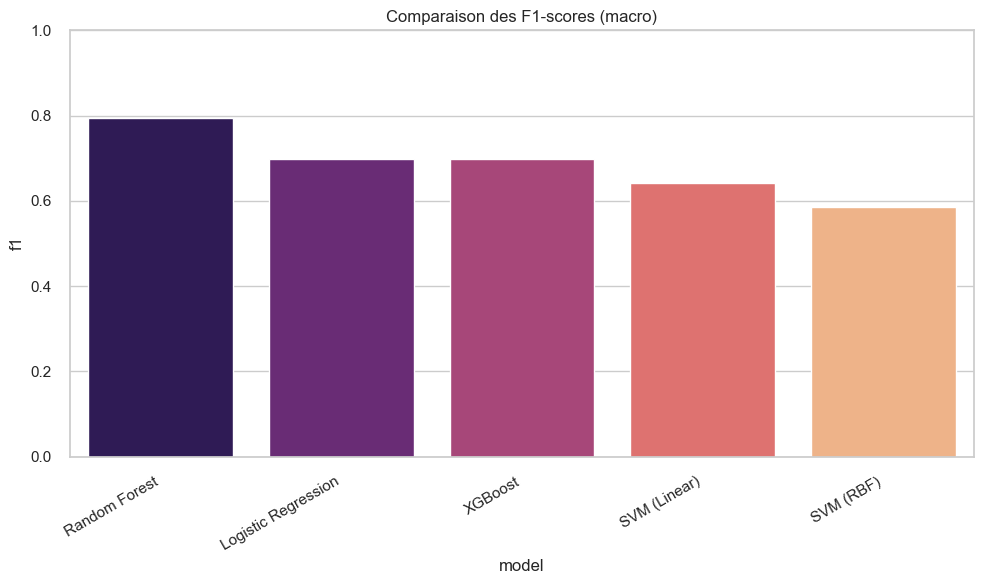

In [16]:

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="model", y="accuracy", palette="viridis")
plt.title("Comparaison des accuracies")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="model", y="f1", palette="magma")
plt.title("Comparaison des F1-scores (macro)")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()



### Interprétation du modèle final


Modèle sélectionné : Random Forest


,feature,importance
12,num__action_count__raccourci,0.029
16,num__action_count__clic_sur_une_grille_d_histo...,0.027
6,num__main_action_share,0.027
14,num__action_count__retour_sur_un_ecran,0.026
15,num__action_count__affichage_d_un_toast,0.025
13,num__action_count__double_clic,0.024
18,num__action_count__filtrage_tri,0.023
9,num__action_count__saisie_dans_un_champ,0.023
2,num__ratio_unique_actions,0.023
3,num__nb_unique_screens,0.022


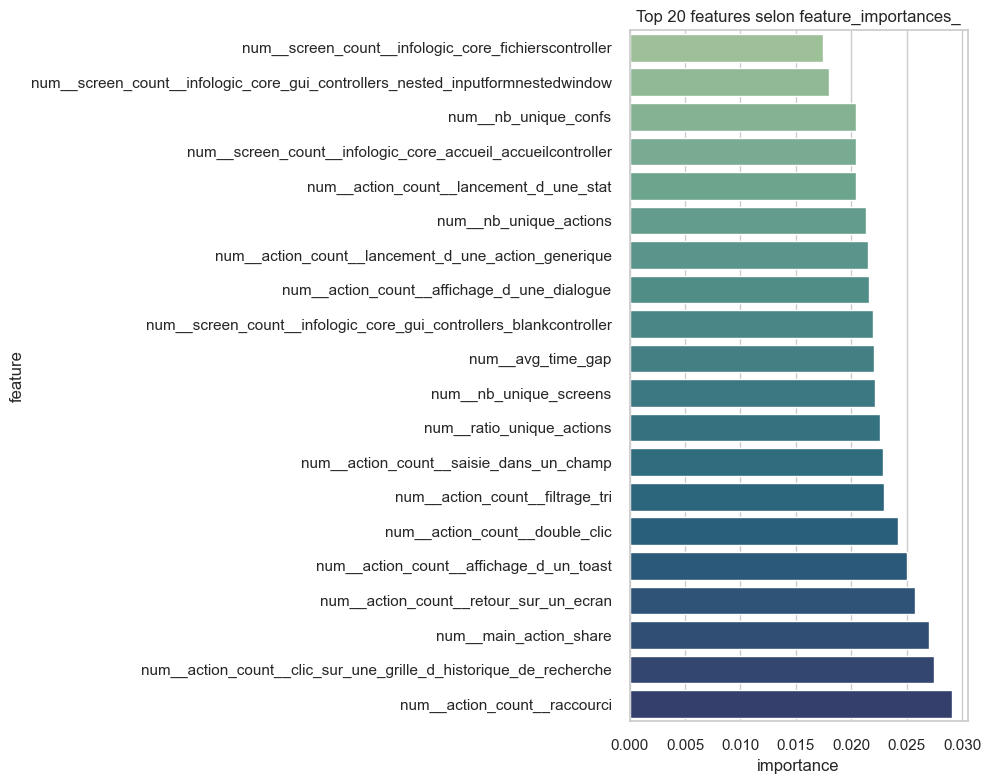

In [17]:
best_model_name = results_df.iloc[0]["model"]
print(f"Modèle sélectionné : {best_model_name}")

best_pipeline = best_models[best_model_name]
preprocessor_fitted = best_pipeline.named_steps["preprocessor"]
model_fitted = best_pipeline.named_steps["model"]


feature_names = preprocessor_fitted.get_feature_names_out()


importance_values = None
importance_type = None

if hasattr(model_fitted, "feature_importances_"):
    importance_values = model_fitted.feature_importances_
    importance_type = "feature_importances_"
elif hasattr(model_fitted, "coef_"):
    coef_ = model_fitted.coef_
    if coef_.ndim == 1:
        importance_values = np.abs(coef_)
    else:
        importance_values = np.mean(np.abs(coef_), axis=0)
    importance_type = "|coef| (moyenne multi-classes)"


importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importance_values})
    .sort_values(by="importance", ascending=False)
    .head(20)
)
display(importance_df)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=importance_df.sort_values(by="importance"),
    x="importance",
    y="feature",
    palette="crest",
)
plt.title(f"Top 20 features selon {importance_type}")
plt.tight_layout()
plt.show()



In [18]:
try:
    import shap

    shap.initjs()

    transformer = best_pipeline.named_steps["preprocessor"]
    model_estimator = best_pipeline.named_steps["model"]

    X_train_transformed = transformer.transform(X_train)
    X_test_transformed = transformer.transform(X_test)

    sample_size = min(200, X_test_transformed.shape[0])
    sample_data = X_test_transformed[:sample_size]

    explainer = shap.Explainer(model_estimator, X_train_transformed)
    shap_values = explainer(sample_data)

    shap.summary_plot(shap_values, feature_names=feature_names, plot_type="bar")
except Exception as exc:
    print(f"Analyse SHAP non disponible : {exc}")


Analyse SHAP non disponible : No module named 'shap'


###  Sauvegarde


In [19]:
artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(exist_ok=True)

pipeline_path = artifacts_dir / "pipeline.joblib"
model_path = artifacts_dir / "model_final.joblib"
label_encoder_path = artifacts_dir / "target_encoder.joblib"

joblib.dump(best_pipeline, pipeline_path)
joblib.dump(best_pipeline, model_path)
joblib.dump(
    {
        "label_encoder": target_encoder,
        "classes": target_encoder.classes_.tolist(),
    },
    label_encoder_path,
)

print(f"Pipeline sauvegardée : {pipeline_path.resolve()}")
print(f"Modèle sauvegardé   : {model_path.resolve()}")
print(f"Encodeur sauvegardé : {label_encoder_path.resolve()}")


Pipeline sauvegardée : C:\Users\natha\PycharmProjects\BE1\data_sci\artifacts\pipeline.joblib
Modèle sauvegardé   : C:\Users\natha\PycharmProjects\BE1\data_sci\artifacts\model_final.joblib
Encodeur sauvegardé : C:\Users\natha\PycharmProjects\BE1\data_sci\artifacts\target_encoder.joblib




 **Modèle retenu** : Random Forest

 On Entraine le modèle sur tout le dataset entier



In [22]:
from sklearn.base import clone

best_model_name = results_df.iloc[0]["model"]
print(f"Selected model for submission: {best_model_name}")

best_pipeline_search = best_models[best_model_name]
final_pipeline = clone(best_pipeline_search)
final_pipeline.fit(X, y)

artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(exist_ok=True)

final_pipeline_path = artifacts_dir / "pipeline_full_train.joblib"
joblib.dump(final_pipeline, final_pipeline_path)
joblib.dump(
    {
        "label_encoder": target_encoder,
        "classes": target_encoder.classes_.tolist(),
    },
    artifacts_dir / "target_encoder_full.joblib",
)
print(f"Full-train pipeline saved to {final_pipeline_path}")




Selected model for submission: Random Forest
Full-train pipeline saved to artifacts\pipeline_full_train.joblib


## Submission Kaggle

In [21]:
from pathlib import Path
from feature_builder import (
    load_sessions,
    compute_top_labels,
    build_label_map,
    compute_row_features,
)

def load_test_sessions(path: Path):
    sessions = []
    with path.open("r", encoding="utf-8") as handle:
        for idx, line in enumerate(handle, 1):
            stripped = line.strip()
            if not stripped:
                continue
            parts = [part.strip() for part in stripped.split(",") if part.strip()]
            if not parts:
                continue
            browser = parts[0]
            events = parts[1:]
            sessions.append(
                {
                    "user": f"test_row_{idx}",
                    "browser": browser,
                    "events": events,
                }
            )
    return sessions

train_sessions = load_sessions(Path("data/train.csv"))
top_actions, top_screens, top_confs, top_chaines = compute_top_labels(train_sessions)
action_labels = build_label_map(top_actions, "action_count")
screen_labels = build_label_map(top_screens, "screen_count")
conf_labels = build_label_map(top_confs, "conf_count")
chaine_labels = build_label_map(top_chaines, "chaine_count")

def sessions_to_features(sessions):
    return [
        compute_row_features(session, action_labels, screen_labels, conf_labels, chaine_labels)
        for session in sessions
    ]

test_sessions = load_test_sessions(Path("data/test.csv"))
row_ids = np.arange(1, len(test_sessions) + 1)
df_test_features = pd.DataFrame(sessions_to_features(test_sessions))

X_submission = df_test_features.drop(columns=["user"], errors="ignore")
if drop_candidates:
    cols_to_drop = [col for col in drop_candidates if col in X_submission.columns]
    if cols_to_drop:
        X_submission = X_submission.drop(columns=cols_to_drop)

X_submission = X_submission.reindex(columns=X.columns)
for col in categorical_features:
    if col in X_submission.columns:
        X_submission[col] = X_submission[col].astype("object")

submission_preds = final_pipeline.predict(X_submission)
submission_labels = target_encoder.inverse_transform(submission_preds)

submission_df = pd.DataFrame(
    {
        "RowId": row_ids,
        "prediction": submission_labels,
    }
)
submission_path = artifacts_dir / "behavior_submission.csv"
submission_df.to_csv(submission_path, index=False, encoding="utf-8")
display(submission_df.head())
print(f"Submission saved to {submission_path.resolve()}")

,RowId,prediction
0,1,hzx
1,2,prb
2,3,hvh
3,4,psg
4,5,cvw


Submission saved to C:\Users\natha\PycharmProjects\BE1\data_sci\artifacts\behavior_submission.csv



- Avec cette soumission, nous obtenons un F1-score de 0.813 sur la plateforme Kaggle.
Ce résultat est légèrement supérieur au score obtenu sur l’ensemble d’entraînement (F1 = 0.794), ce qui indique une bonne capacité de généralisation du modèle et aucun signe d’overfitting marqué